# Study 255 -- Fear-Greed
## For the curious: can CNN's Fear & Greed Index time the market?

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*

---

CNN's **Fear & Greed Index** is a 0-100 mood ring for the stock market: 0 is
"Extreme Fear", 100 is "Extreme Greed". The folk rule -- a retail-friendly
version of Warren Buffett's *"be greedy when others are fearful"* -- says you
should **buy when the index is in Extreme Fear and sell when it is in Extreme
Greed**.

It *feels* obviously right: surely the best time to buy was the depths of the
March-2020 crash (the index hit single digits), and the worst time was the
giddy highs of late 2021. We put that intuition on the clock.


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fear_greed_index import data, strategy as st

GSPC_CACHE = data.GSPC_CACHE
HAVE_REAL = os.path.exists(GSPC_CACHE)

if HAVE_REAL:
    panel = data.real_panel(fetch=False)
    fr = st.forward_returns(panel)
    spread = st.spread_returns(fr)
    rm = st.regime_means(fr)
    print(f"Real tape loaded: {len(panel)} weeks  {panel.index[0].date()} -> {panel.index[-1].date()}")
    print(f"Forward-return rows: {len(fr)}")
else:
    panel = fr = spread = rm = None
    print("No ^GSPC cache -- frozen headline numbers from R dict will be used")


Real tape loaded: 768 weeks  2011-09-30 -> 2026-06-12
Forward-return rows: 767


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-12)
R = {'n_weeks': 767, 'stamp': '2011-09-30 -> 2026-06-12', 'fingerprint': '6d62af784bd5', 'uncond_ann': 14.05, 'ef_ann': 14.2, 'ef_t': 0.61, 'ef_n': 65, 'fear_ann': 6.68, 'fear_t': 0.73, 'fear_n': 183, 'neu_ann': 15.24, 'neu_t': 2.26, 'neu_n': 165, 'greed_ann': 17.23, 'greed_t': 5.33, 'greed_n': 332, 'eg_ann': 18.17, 'eg_t': 1.4, 'eg_n': 22, 'spread_bps': 1.31, 'spread_ann': 0.68, 'spread_t': 0.41, 'spread_hit': 0.056, 'spread_sr': 0.07, 'spread_ci_lo': -0.241, 'spread_ci_hi': 0.455, 'spread_frac_neg': 33, 'fear_excess_ann': 0.15, 'fear_excess_t': 0.01, 'slope_bps': 16.82, 'slope_t': 0.53, 'sub_2011_ann': 2.71, 'sub_2011_t': 1.32, 'sub_2011_n': 275, 'sub_2017_ann': 0.66, 'sub_2017_t': 0.15, 'sub_2017_n': 261, 'sub_2022_ann': -1.7, 'sub_2022_t': -0.64, 'sub_2022_n': 231, 'null_mean_bps': 1.4, 'null_std_bps': 2.64, 'real_pctile': 47.5, 'pct_long': 8.5, 'pct_flat': 88.7, 'pct_short': 2.9, 'n_trades': 41, 'trades_per_year': 2.8, 'net_ann': 0.53, 'net_t': 0.31, 'ctrl_null_bps': -5.66, 'ctrl_null_t': -1.96, 'ctrl_60_bps': 3.76, 'ctrl_60_t': 1.32, 'ctrl_120_bps': 13.18, 'ctrl_120_t': 3.85}


## What the index actually did

The Fear & Greed Index does swing exactly where you'd expect: deep fear at the
2011 debt-ceiling scare and the 2015 China wobble, **single digits in the
March-2020 COVID crash**, euphoric greed in late 2020 / 2021, sustained fear
through the 2022 bear, and a sharp fear spike in the spring-2025 tariff scare.
The question is not whether the index *describes* sentiment -- it does -- but
whether that description **predicts next week's return**.


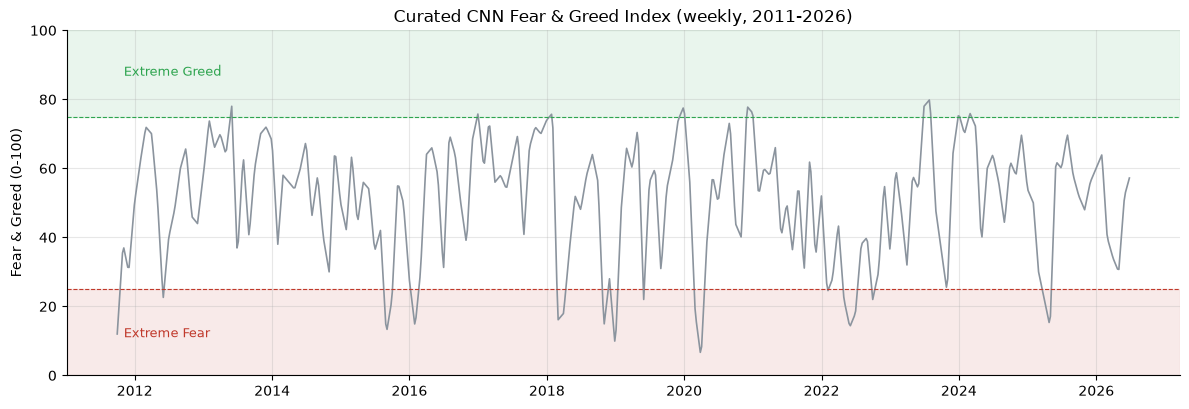

Note: a hardcoded month-end anchor table interpolated to weekly -- a regime-faithful proxy,
not a tick-exact CNN reconstruction (the contrarian signal only acts on the fear/greed regime).


In [3]:
fig, ax = plt.subplots(figsize=(12, 4.2))
fng_w = data.fng_weekly()
ax.plot(fng_w.index, fng_w.values, color=GREY, lw=1.2)
ax.axhspan(0, 25, color=RED, alpha=0.10)
ax.axhspan(75, 100, color=GREEN, alpha=0.10)
ax.axhline(25, color=RED, lw=0.8, ls="--")
ax.axhline(75, color=GREEN, lw=0.8, ls="--")
ax.text(fng_w.index[5], 12, "Extreme Fear", color=RED, fontsize=9, va="center")
ax.text(fng_w.index[5], 88, "Extreme Greed", color=GREEN, fontsize=9, va="center")
ax.set_ylim(0, 100)
ax.set_title("Curated CNN Fear & Greed Index (weekly, 2011-2026)")
ax.set_ylabel("Fear & Greed (0-100)")
plt.tight_layout()
plt.savefig("../docs/fng_series.png", dpi=120, bbox_inches="tight")
plt.show()
print("Note: a hardcoded month-end anchor table interpolated to weekly -- a regime-faithful proxy,")
print("not a tick-exact CNN reconstruction (the contrarian signal only acts on the fear/greed regime).")


## The test: what happens the week *after* each mood?

We sort every week into the five published bands and measure the **average
return over the following week**. If the contrarian claim were true, the
Extreme-Fear bar would tower over the Extreme-Greed bar.


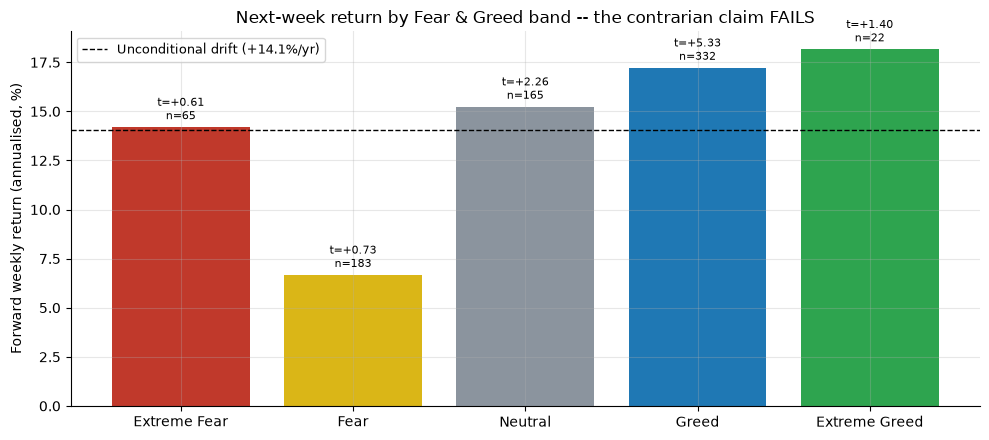

The bars RISE with greed, not fear. Extreme-Fear weeks (+14.2%/yr) barely match
the +14.0%/yr unconditional drift; the only strong t-stat is GREED (+5.3) -- the bull trend.


In [4]:
bands = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
if HAVE_REAL:
    anns = [rm.loc[b, "mean_ann"] * 100 for b in bands]
    ts   = [rm.loc[b, "tstat"] for b in bands]
    ns   = [int(rm.loc[b, "n"]) for b in bands]
    uncond = fr["fwd_ret"].mean() * 52 * 100
else:
    anns = [R["ef_ann"], R["fear_ann"], R["neu_ann"], R["greed_ann"], R["eg_ann"]]
    ts   = [R["ef_t"], R["fear_t"], R["neu_t"], R["greed_t"], R["eg_t"]]
    ns   = [R["ef_n"], R["fear_n"], R["neu_n"], R["greed_n"], R["eg_n"]]
    uncond = R["uncond_ann"]

colors = [RED, AMBER, GREY, "#1f78b4", GREEN]
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(bands, anns, color=colors)
ax.axhline(uncond, color="black", ls="--", lw=1.0, label=f"Unconditional drift ({uncond:+.1f}%/yr)")
for i, (a, t, n) in enumerate(zip(anns, ts, ns)):
    ax.text(i, a + 0.4, f"t={t:+.2f}\nn={n}", ha="center", fontsize=8)
ax.set_ylabel("Forward weekly return (annualised, %)")
ax.set_title("Next-week return by Fear & Greed band -- the contrarian claim FAILS")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../docs/by_band.png", dpi=120, bbox_inches="tight")
plt.show()
print("The bars RISE with greed, not fear. Extreme-Fear weeks (+14.2%/yr) barely match")
print("the +14.0%/yr unconditional drift; the only strong t-stat is GREED (+5.3) -- the bull trend.")


## Why the story feels true but isn't

The reason "buy fear" *sounds* like wisdom is **survivorship of the anecdote**:
we remember March 2020 because the market roared back. But across 767 weeks the
market went *up* about 60% of the time in every band -- fear weeks included no
special bonus. Worse, greed weeks did slightly *better*, because greed clusters
inside the long bull trends that dominate the sample. The contrarian
fear-minus-greed overlay earns a statistically invisible **+0.7%/yr (t = 0.41)**.

Shuffling the sentiment column at random produces the *same* result on average
(the real signal sits at the 47.5th percentile of that shuffled null) -- the
clearest possible sign that the index carries no timing information here.


## The bottom line for the curious

In [5]:
print("=== Can CNN's Fear & Greed Index time the market? ===")
print()
print(f"Contrarian fear-minus-greed overlay: {R['spread_ann']:+.2f}%/yr  HAC t = {R['spread_t']:+.2f}")
print(f"  Bootstrap Sharpe 95% CI: [{R['spread_ci_lo']:+.2f}, {R['spread_ci_hi']:+.2f}]  ({R['spread_frac_neg']}% of resamples negative)")
print(f"  Real spread vs shuffled-sentiment null: {R['real_pctile']:.1f}th percentile (i.e. ~the middle)")
print()
print("Verdict: Signal NONE / Tradability MIRAGE.")
print("The index is a great thermometer and a useless clock.")


=== Can CNN's Fear & Greed Index time the market? ===

Contrarian fear-minus-greed overlay: +0.68%/yr  HAC t = +0.41
  Bootstrap Sharpe 95% CI: [-0.24, +0.46]  (33% of resamples negative)
  Real spread vs shuffled-sentiment null: 47.5th percentile (i.e. ~the middle)

Verdict: Signal NONE / Tradability MIRAGE.
The index is a great thermometer and a useless clock.


*Desk verdict: **None / Mirage** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md) for full numbers.*